In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, random_split
import pandas as pd
import cv2
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [99]:
CSV_PATH = "../annotations.csv"
IMG_DIR = "../dataset_prepro/"

In [100]:
class DatasetFaces(Dataset):   

    def __init__(self, csv_file, img_dir, transform=None, file_extension='.jpg'):
        """
        Args:
            csv_file (string): Chemin vers le fichier CSV.
            img_dir (string): Répertoire avec toutes les images.
            transform (callable, optional): Transformations à appliquer.
            file_extension (string): Extension à ajouter aux noms de fichiers
                                     (ex: '.jpg', '.png')
        """
        # --- Modification ici ---
        # On utilise 'filename' comme index du DataFrame
        self.annotations = pd.read_csv(csv_file, index_col='filename')
        
        # On stocke la liste des noms de fichiers (l'index) 
        # pour y accéder par un entier `idx`
        self.img_names = self.annotations.index.tolist()
        # --- Fin Modification ---
        
        self.img_dir = img_dir
        self.transform = transform
        self.file_extension = file_extension # Pour gérer "s1_00000" -> "s1_00000.jpg"

    def __len__(self):
        # La longueur est le nombre de noms de fichiers
        return len(self.img_names)

    def __getitem__(self, idx):
        """
        Récupère un échantillon (image + labels) à l'index donné.
        """
        
        # 1. Obtenir le nom du fichier (qui est notre index) via l'entier `idx`
        img_name_base = self.img_names[idx] # ex: "s1_00000"
        
        # 2. Construire le chemin complet de l'image
        # On ajoute l'extension de fichier que vous avez spécifiée
        img_name_with_ext = img_name_base + self.file_extension
        img_path = os.path.join(self.img_dir, img_name_with_ext)
        
        # 3. Charger l'image
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            print(f"Erreur : Image non trouvée à {img_path}")
            # Vous pouvez retourner None ou un tenseur vide
            # pour le sauter dans le DataLoader (si vous gérez les `None`)
            return None, None 

        # 4. Obtenir TOUS les labels en utilisant le nom du fichier (l'index)
        # .loc[img_name_base] -> Récupère la ligne par son index (ex: "s1_00000")
        # .values -> Récupère les valeurs de toutes les colonnes de labels
        labels = self.annotations.loc[img_name_base].values
        
        # 5. Convertir les labels en tenseur
        # dtype=torch.float32 est souvent requis pour les fonctions de perte 
        # de classification multi-label (comme BCEWithLogitsLoss)
        labels = torch.tensor(labels.astype(float), dtype=torch.float32)
        # `labels` sera un tenseur de type [1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0]

        # 6. Appliquer les transformations
        if self.transform:
            image = self.transform(image)

        # 7. Retourner l'image et le tenseur de labels
        return image, labels
    


In [101]:
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# 1. Instancier votre dataset complet (comme avant)
full_dataset = DatasetFaces(csv_file=CSV_PATH,
                              img_dir=IMG_DIR,
                              transform=data_transform,
                              file_extension=".png")

# 2. Calculer les tailles
total_size = len(full_dataset)
train_size = int(0.7 * total_size) # 70%
test_size = total_size - train_size # Le reste (30%)

print(f"Total: {total_size} | Train: {train_size} | Test: {test_size}")

# 3. Fixer le générateur aléatoire (IMPORTANT pour la reproductibilité)
# Cela assure que le split est le même à chaque fois que vous lancez le code
generator = torch.Generator().manual_seed(42)

# 4. Diviser le dataset
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size], generator=generator)

# 5. Créer les DataLoaders
# - Train : shuffle=True (pour bien mélanger pendant l'apprentissage)
# - Test  : shuffle=False (inutile de mélanger pour l'évaluation)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Total: 15890 | Train: 11123 | Test: 4767


In [102]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3,8,3,padding=1), nn.ReLU(),
            nn.Conv2d(8,16,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Note : 32*16*16 implique que vos images d'entrée font 64x64
        # (64 -> 32 -> 16)
        self.common_fc = nn.Sequential(
            nn.Linear(32*16*16, 256), nn.ReLU(),
        )

        # --- Têtes Binaires (sortie 1 logit) ---
        # Classification de la barbe
        self.classifier_barbe = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(), # J'ajoute un ReLU ici
            nn.Linear(64, 1)
        )

        # Classification des moustaches
        self.classifier_moustache = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

        # Classification des lunettes
        self.classifier_lunettes = nn.Sequential(
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
        
        # --- Branche "Cheveux" ---
        
        # 1. Couche intermédiaire pour les caractéristiques des cheveux
        self.classifier_cheveux_features = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU() # J'ajoute un ReLU ici
        )

        # 2. Tête Multi-classe (sortie 3 logits)
        self.classifier_taille_cheveux = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 3) # Sortie pour 3 classes (long, court, chauve?)
        )

        # 3. Tête Multi-classe (sortie 5 logits)
        # ⚠️ CORRECTION : Renommé pour éviter l'écrasement
        self.classifier_couleur_cheveux = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 5) # Sortie pour 5 classes de couleur
        )

    def forward(self, x):
        # 1. Partie convolutive
        x = self.conv(x)
        
        # 2. Aplatir et passer dans le tronc commun
        x = x.view(x.size(0), -1) # ou torch.flatten(x, 1)
        common_features = self.common_fc(x) # Shape: [batch_size, 256]

        # 3. Têtes binaires
        out_barbe = self.classifier_barbe(common_features)
        out_moustache = self.classifier_moustache(common_features)
        out_lunettes = self.classifier_lunettes(common_features)
        
        # 4. Branche "Cheveux"
        cheveux_features = self.classifier_cheveux_features(common_features) # Shape: [batch_size, 128]
        
        # 5. Têtes multi-classes (cheveux)
        out_taille_cheveux = self.classifier_taille_cheveux(cheveux_features)
        out_couleur_cheveux = self.classifier_couleur_cheveux(cheveux_features)

        # 6. Retourner toutes les sorties (logits)
        return [out_barbe, out_moustache, out_lunettes, out_taille_cheveux, out_couleur_cheveux]

In [103]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim # Correction de l'import standard

# --- Configuration ---
num_epochs = 5 # Un peu plus d'époques pour voir l'évolution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assurez-vous que le modèle est sur le bon device
model = CNN().to(device) 

criterion_binaire = nn.BCEWithLogitsLoss().to(device)
criterion_multiclasse = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- Boucle d'entraînement ---

for epoch in range(num_epochs):
    print(f"\n{'='*10} Epoch {epoch+1}/{num_epochs} {'='*10}")
    
    model.train() # Important : active le mode entraînement
    
    # 1. Initialisation des métriques pour cette époque
    epoch_loss = 0.0
    total_samples = 0
    
    # Compteurs de bonnes réponses
    correct_barbe = 0
    correct_moustache = 0
    correct_lunettes = 0
    correct_taille = 0
    correct_couleur = 0

    # Barre de progression
    progress_bar = tqdm(train_loader, desc="Entraînement", unit="batch")

    for images, all_labels_batch in progress_bar:
        
        images = images.to(device)
        all_labels_batch = all_labels_batch.to(device)
        
        # --- Forward pass ---
        outputs = model(images)
        out_barbe, out_moustache, out_lunettes, out_taille, out_couleur = outputs
        
        # --- Préparation des Vrais Labels ---
        lab_barbe = all_labels_batch[:, 0].float()
        lab_moustache = all_labels_batch[:, 1].float()
        lab_lunettes = all_labels_batch[:, 2].float()

        # Conversion One-Hot -> Index pour les multi-classes
        lab_taille = torch.argmax(all_labels_batch[:, 3:6], dim=1)
        lab_couleur = torch.argmax(all_labels_batch[:, 6:11], dim=1)

        # --- Calcul de la Loss ---
        loss_barbe = criterion_binaire(out_barbe.squeeze(), lab_barbe)
        loss_moustache = criterion_binaire(out_moustache.squeeze(), lab_moustache)
        loss_lunettes = criterion_binaire(out_lunettes.squeeze(), lab_lunettes)
        loss_taille = criterion_multiclasse(out_taille, lab_taille)
        loss_couleur = criterion_multiclasse(out_couleur, lab_couleur)
        
        total_loss = loss_barbe + loss_moustache + loss_lunettes + loss_taille + loss_couleur
        
        # --- Rétropropagation ---
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # --- STATS : Calcul des prédictions correctes ---
        batch_size = images.size(0)
        total_samples += batch_size
        
        with torch.no_grad(): # Pas besoin de gradients pour les stats
            # 1. Binaires : Si sigmoid(logit) > 0.5 -> Classe 1, sinon 0
            pred_barbe = (torch.sigmoid(out_barbe.squeeze()) > 0.5).float()
            correct_barbe += (pred_barbe == lab_barbe).sum().item()
            
            pred_moustache = (torch.sigmoid(out_moustache.squeeze()) > 0.5).float()
            correct_moustache += (pred_moustache == lab_moustache).sum().item()
            
            pred_lunettes = (torch.sigmoid(out_lunettes.squeeze()) > 0.5).float()
            correct_lunettes += (pred_lunettes == lab_lunettes).sum().item()
            
            # 2. Multi-classes : Argmax pour trouver l'index gagnant
            pred_taille = torch.argmax(out_taille, dim=1)
            correct_taille += (pred_taille == lab_taille).sum().item()
            
            pred_couleur = torch.argmax(out_couleur, dim=1)
            correct_couleur += (pred_couleur == lab_couleur).sum().item()

        # Mise à jour de la loss moyenne et de la barre
        epoch_loss += total_loss.item()
        
        # On affiche la loss et un aperçu de l'accuracy 'taille' dans la barre
        curr_acc_taille = (pred_taille == lab_taille).sum().item() / batch_size
        progress_bar.set_postfix({
            'loss': f"{total_loss.item():.3f}", 
            'acc_taille': f"{curr_acc_taille:.0%}"
        })
    
    # --- Fin de l'époque : Affichage du rapport global ---
    avg_loss = epoch_loss / len(train_loader)
    
    # Calcul des pourcentages finaux
    acc_barbe = correct_barbe / total_samples * 100
    acc_moustache = correct_moustache / total_samples * 100
    acc_lunettes = correct_lunettes / total_samples * 100
    acc_taille = correct_taille / total_samples * 100
    acc_couleur = correct_couleur / total_samples * 100

    print(f"\n📊 Fin de l'Epoch {epoch+1}")
    print(f"   📉 Loss Moyenne : {avg_loss:.4f}")
    print(f"   ✅ Accuracies (Précision sur le train) :")
    print(f"      🧔 Barbe     : {acc_barbe:.2f}%")
    print(f"      👨 Moustache : {acc_moustache:.2f}%")
    print(f"      👓 Lunettes  : {acc_lunettes:.2f}%")
    print(f"      💇 Taille    : {acc_taille:.2f}%")
    print(f"      🎨 Couleur   : {acc_couleur:.2f}%")
    print("-" * 30)


========== Epoch 1/5 ==========


Entraînement: 100%|██████████| 348/348 [00:27<00:00, 12.67batch/s, loss=0.720, acc_taille=100%]



📊 Fin de l'Epoch 1
   📉 Loss Moyenne : 1.4589
   ✅ Accuracies (Précision sur le train) :
      🧔 Barbe     : 84.96%
      👨 Moustache : 88.11%
      👓 Lunettes  : 87.10%
      💇 Taille    : 91.60%
      🎨 Couleur   : 87.23%
------------------------------

========== Epoch 2/5 ==========


Entraînement: 100%|██████████| 348/348 [00:27<00:00, 12.68batch/s, loss=0.723, acc_taille=89%] 



📊 Fin de l'Epoch 2
   📉 Loss Moyenne : 0.3592
   ✅ Accuracies (Précision sur le train) :
      🧔 Barbe     : 96.57%
      👨 Moustache : 96.22%
      👓 Lunettes  : 97.65%
      💇 Taille    : 98.93%
      🎨 Couleur   : 97.44%
------------------------------

========== Epoch 3/5 ==========


...


📊 Fin de l'Epoch 3
   📉 Loss Moyenne : 0.1764
   ✅ Accuracies (Précision sur le train) :
      🧔 Barbe     : 98.49%
      👨 Moustache : 98.07%
      👓 Lunettes  : 99.42%
      💇 Taille    : 99.54%
      🎨 Couleur   : 98.16%
------------------------------

========== Epoch 4/5 ==========


Entraînement: 100%|██████████| 348/348 [00:30<00:00, 11.55batch/s, loss=0.314, acc_taille=100%]



📊 Fin de l'Epoch 4
   📉 Loss Moyenne : 0.0987
   ✅ Accuracies (Précision sur le train) :
      🧔 Barbe     : 99.32%
      👨 Moustache : 98.95%
      👓 Lunettes  : 99.87%
      💇 Taille    : 99.76%
      🎨 Couleur   : 98.71%
------------------------------

========== Epoch 5/5 ==========


Entraînement: 100%|██████████| 348/348 [00:29<00:00, 11.72batch/s, loss=0.034, acc_taille=100%]


📊 Fin de l'Epoch 5
   📉 Loss Moyenne : 0.0745
   ✅ Accuracies (Précision sur le train) :
      🧔 Barbe     : 99.49%
      👨 Moustache : 99.28%
      👓 Lunettes  : 99.69%
      💇 Taille    : 99.86%
      🎨 Couleur   : 99.16%
------------------------------


--- Démarrage de l'évaluation sur le dataset de test ---


Inférence: 100%|██████████| 149/149 [00:06<00:00, 21.90it/s]



==================== RÉSULTATS : BARBE ====================
✅ Accuracy (Précision globale) : 99.24%

📊 Rapport de Classification :
              precision    recall  f1-score   support

         Non       0.99      1.00      0.99      3288
         Oui       0.99      0.98      0.99      1479

    accuracy                           0.99      4767
   macro avg       0.99      0.99      0.99      4767
weighted avg       0.99      0.99      0.99      4767



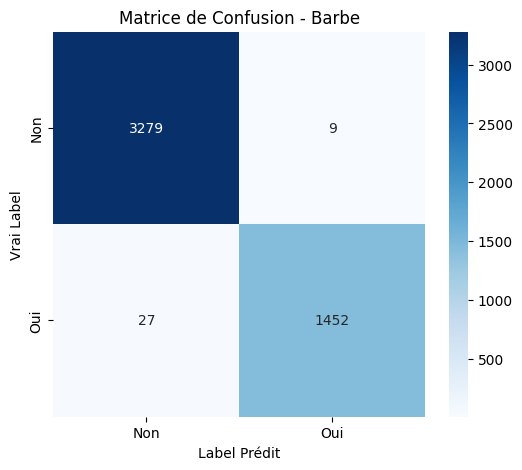


==================== RÉSULTATS : MOUSTACHE ====================
✅ Accuracy (Précision globale) : 99.24%

📊 Rapport de Classification :
              precision    recall  f1-score   support

         Non       1.00      0.99      0.99      3605
         Oui       0.98      0.99      0.98      1162

    accuracy                           0.99      4767
   macro avg       0.99      0.99      0.99      4767
weighted avg       0.99      0.99      0.99      4767



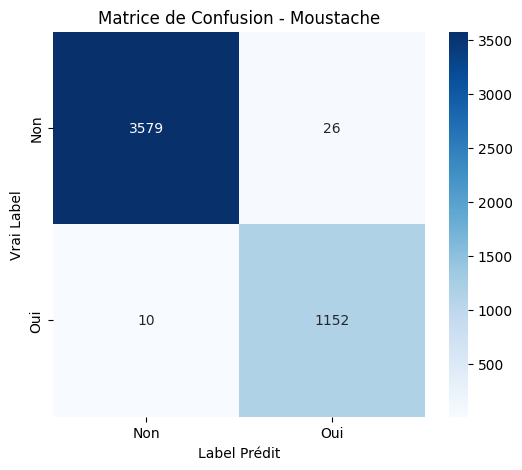


==================== RÉSULTATS : LUNETTES ====================
✅ Accuracy (Précision globale) : 99.37%

📊 Rapport de Classification :
              precision    recall  f1-score   support

         Non       1.00      0.99      0.99      2979
         Oui       0.99      0.99      0.99      1788

    accuracy                           0.99      4767
   macro avg       0.99      0.99      0.99      4767
weighted avg       0.99      0.99      0.99      4767



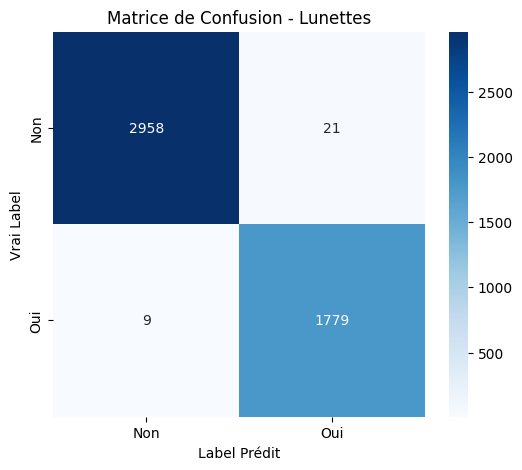


==================== RÉSULTATS : TAILLE ====================
✅ Accuracy (Précision globale) : 99.69%

📊 Rapport de Classification :
              precision    recall  f1-score   support

       Longs       1.00      1.00      1.00      2616
      Courts       1.00      1.00      1.00      1811
      Chauve       0.99      0.99      0.99       340

    accuracy                           1.00      4767
   macro avg       1.00      0.99      0.99      4767
weighted avg       1.00      1.00      1.00      4767



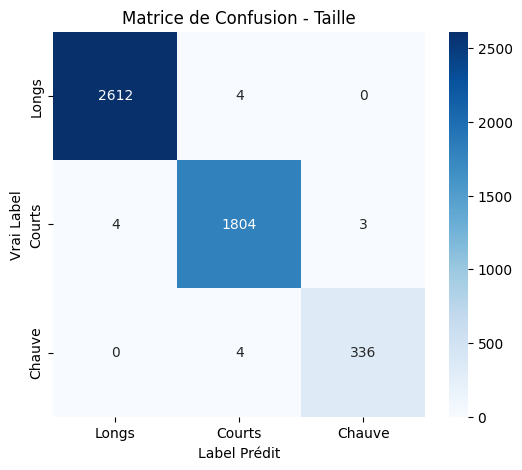


==================== RÉSULTATS : COULEUR ====================
✅ Accuracy (Précision globale) : 97.57%

📊 Rapport de Classification :
              precision    recall  f1-score   support

       Blond       1.00      0.94      0.97      1239
     Chatain       0.98      0.99      0.99      1493
        Roux       0.93      0.96      0.95       510
        Brun       0.99      0.98      0.99       514
   Gris/Bleu       0.96      1.00      0.98      1011

    accuracy                           0.98      4767
   macro avg       0.97      0.98      0.97      4767
weighted avg       0.98      0.98      0.98      4767



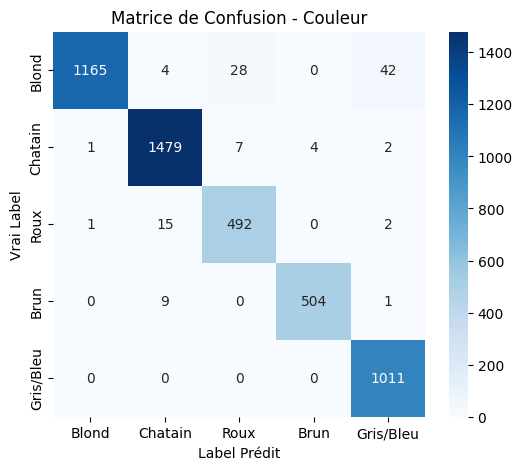

In [104]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def evaluate_model(model, data_loader, device):
    model.eval() # Mode évaluation
    
    # --- 1. Initialisation des conteneurs pour stocker les résultats ---
    # On utilise des dictionnaires pour organiser les 5 tâches
    results = {
        "Barbe":      {"true": [], "pred": [], "classes": ["Non", "Oui"]},
        "Moustache":  {"true": [], "pred": [], "classes": ["Non", "Oui"]},
        "Lunettes":   {"true": [], "pred": [], "classes": ["Non", "Oui"]},
        "Taille":     {"true": [], "pred": [], "classes": ["Longs", "Courts", "Chauve"]}, # Ordre supposé
        "Couleur":    {"true": [], "pred": [], "classes": ["Blond", "Chatain", "Roux", "Brun", "Gris/Bleu"]} # Ordre supposé
    }

    print("--- Démarrage de l'évaluation sur le dataset de test ---")
    
    with torch.no_grad():
        for images, all_labels in tqdm(data_loader, desc="Inférence"):
            images = images.to(device)
            all_labels = all_labels.to(device)
            
            # --- A. Prédictions du modèle ---
            outputs = model(images)
            out_barbe, out_moustache, out_lunettes, out_taille, out_couleur = outputs
            
            # --- B. Traitement des sorties (Logits -> Prédictions finales) ---
            
            # 1. Binaires (Sigmoid > 0.5)
            pred_barbe = (torch.sigmoid(out_barbe) > 0.5).float().cpu().numpy()
            pred_moustache = (torch.sigmoid(out_moustache) > 0.5).float().cpu().numpy()
            pred_lunettes = (torch.sigmoid(out_lunettes) > 0.5).float().cpu().numpy()
            
            # 2. Multi-classes (Argmax)
            pred_taille = torch.argmax(torch.softmax(out_taille, dim=1), dim=1).cpu().numpy()
            pred_couleur = torch.argmax(torch.softmax(out_couleur, dim=1), dim=1).cpu().numpy()
            
            # --- C. Traitement des Vrais Labels (Ground Truth) ---
            # On récupère les colonnes comme dans l'entraînement
            
            true_barbe = all_labels[:, 0].cpu().numpy()
            true_moustache = all_labels[:, 1].cpu().numpy()
            true_lunettes = all_labels[:, 2].cpu().numpy()
            
            # Conversion One-Hot -> Index pour les multi-classes
            true_taille = torch.argmax(all_labels[:, 3:6], dim=1).cpu().numpy()
            true_couleur = torch.argmax(all_labels[:, 6:11], dim=1).cpu().numpy()
            
            # --- D. Stockage ---
            results["Barbe"]["true"].extend(true_barbe)
            results["Barbe"]["pred"].extend(pred_barbe)
            
            results["Moustache"]["true"].extend(true_moustache)
            results["Moustache"]["pred"].extend(pred_moustache)
            
            results["Lunettes"]["true"].extend(true_lunettes)
            results["Lunettes"]["pred"].extend(pred_lunettes)
            
            results["Taille"]["true"].extend(true_taille)
            results["Taille"]["pred"].extend(pred_taille)
            
            results["Couleur"]["true"].extend(true_couleur)
            results["Couleur"]["pred"].extend(pred_couleur)

    # --- 2. Affichage des statistiques ---
    
    for task_name, data in results.items():
        print(f"\n{'='*20} RÉSULTATS : {task_name.upper()} {'='*20}")
        
        y_true = data["true"]
        y_pred = data["pred"]
        class_names = data["classes"]
        
        # 1. Accuracy globale
        acc = accuracy_score(y_true, y_pred)
        print(f"✅ Accuracy (Précision globale) : {acc:.2%}")
        
        # 2. Rapport détaillé (Precision, Recall, F1-Score par classe)
        print("\n📊 Rapport de Classification :")
        print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
        
        # 3. Matrice de Confusion (Graphique)
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Matrice de Confusion - {task_name}")
        plt.ylabel('Vrai Label')
        plt.xlabel('Label Prédit')
        plt.show()

# --- Lancer l'évaluation ---
# Assurez-vous que 'model', 'test_loader' et 'device' sont définis
evaluate_model(model, test_loader, device)